# Классификация заказов «Mafia Time»
## Дисциплина: Программирование и информационные технологии в научно-исследовательской работе

**Методы:** Decision Tree, Random Forest, K-Nearest Neighbors (KNN)  
**Данные:** Синтетический датасет заказов (имитация выгрузки из amoCRM + Точка Банк)  
**Задача:** Прогнозирование вероятности оплаты заказа — двухклассовая классификация (оплачен / не оплачен)

## 1. Импорт библиотек

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, accuracy_score, f1_score
)
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
plt.rcParams['figure.figsize'] = (10, 6)
print('Библиотеки загружены успешно')

Библиотеки загружены успешно


## 2. Генерация синтетического датасета

Датасет имитирует выгрузку заказов из CRM-системы amoCRM компании «Mafia Time».  
Каждая строка — один заказ. Признаки:
- `order_amount` — сумма заказа (руб.)
- `days_to_event` — дней до мероприятия на момент выставления счёта
- `client_orders_history` — количество предыдущих заказов клиента
- `response_time_hours` — время ответа клиента на счёт (часов)
- `is_corporate` — корпоративный ли клиент (0/1)
- `has_contract` — был ли подписан договор (0/1)
- `paid` — **целевая переменная**: оплачен ли заказ (1=да, 0=нет)

In [15]:
n = 500

order_amount       = np.random.normal(9000, 3500, n).clip(2000, 20000)
days_to_event      = np.random.randint(1, 90, n)
client_history     = np.random.randint(0, 15, n)
response_time      = np.random.exponential(6, n).clip(0.5, 48)
is_corporate       = np.random.binomial(1, 0.35, n)
has_contract       = np.random.binomial(1, 0.6, n)

# Логика целевой переменной (реалистичная)
log_odds = (
    -0.5
    + 0.00008  * order_amount          # меньший счёт — выше вероятность оплаты
    * -1
    + 0.012    * days_to_event         # больше времени → клиент успевает оплатить
    + 0.15     * client_history        # постоянные клиенты платят чаще
    - 0.04     * response_time         # медленный ответ → хуже конверсия
    + 0.8      * is_corporate          # корпоративные надёжнее
    + 1.2      * has_contract          # договор сильно повышает шанс оплаты
    + np.random.normal(0, 0.4, n)      # шум
)
prob = 1 / (1 + np.exp(-log_odds))
paid = (np.random.uniform(0, 1, n) < prob).astype(int)

df = pd.DataFrame({
    'order_amount':           order_amount.round(0),
    'days_to_event':          days_to_event,
    'client_orders_history':  client_history,
    'response_time_hours':    response_time.round(1),
    'is_corporate':           is_corporate,
    'has_contract':           has_contract,
    'paid':                   paid
})

print(f'Датасет: {df.shape[0]} заказов, {df.shape[1]} признаков')
print(f'Оплачено: {paid.sum()} ({paid.mean()*100:.1f}%) | Не оплачено: {n-paid.sum()} ({(1-paid.mean())*100:.1f}%)')
df.describe().round(2)

Датасет: 500 заказов, 7 признаков
Оплачено: 361 (72.2%) | Не оплачено: 139 (27.8%)


,order_amount,days_to_event,client_orders_history,response_time_hours,is_corporate,has_contract,paid
count,500.00,500.00,500.00,500.00,500.00,500.00,500.00
mean,9035.91,43.97,7.34,6.12,0.37,0.62,0.72
std,3374.13,25.57,4.38,6.32,0.48,0.49,0.45
min,2000.00,1.00,0.00,0.50,0.00,0.00,0.00
25%,6549.00,23.00,3.00,1.60,0.00,0.00,0.00
50%,9045.00,43.00,8.00,4.20,0.00,1.00,1.00
75%,11229.00,65.25,11.00,7.90,1.00,1.00,1.00
max,20000.00,89.00,14.00,44.70,1.00,1.00,1.00


## 3. Разведочный анализ (EDA)

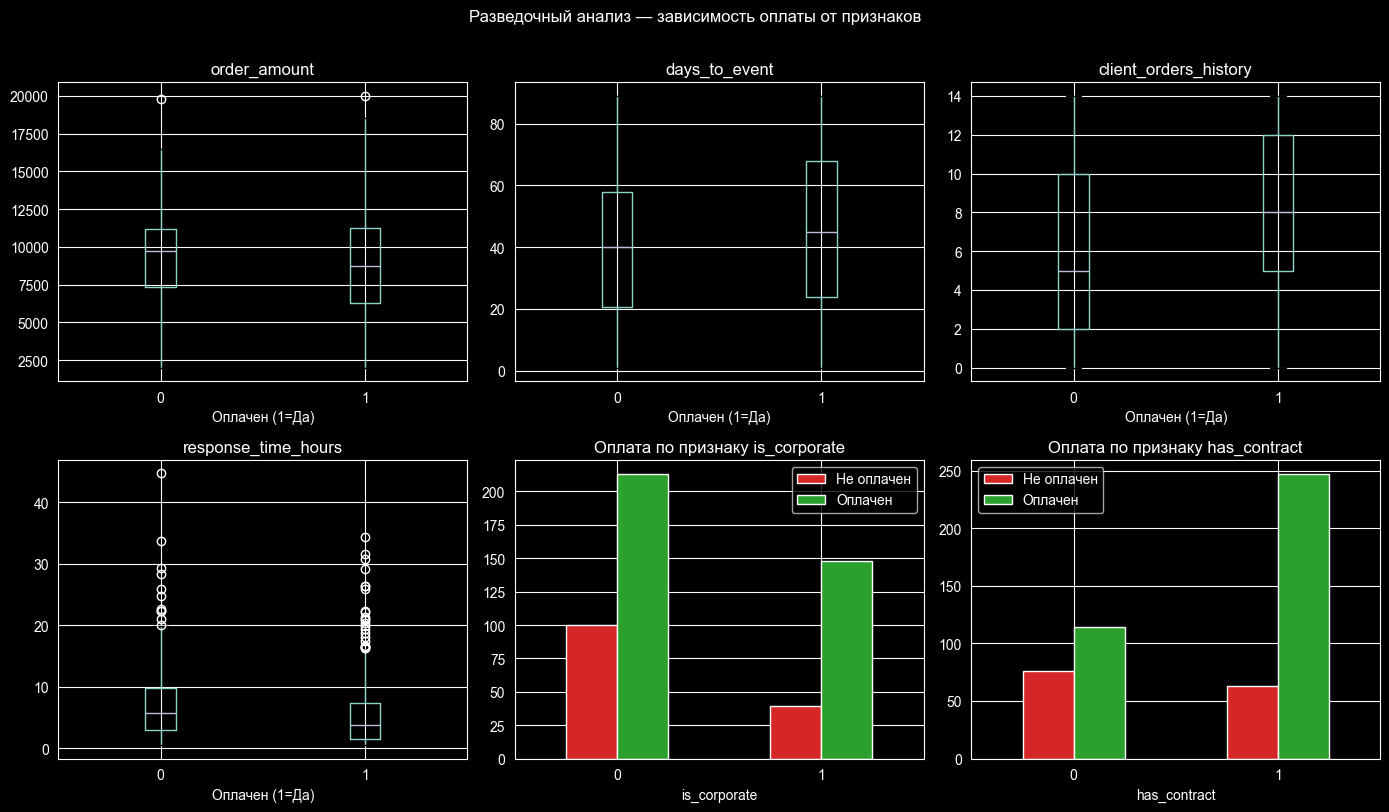

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

num_features = ['order_amount', 'days_to_event', 'client_orders_history', 'response_time_hours']
cat_features = ['is_corporate', 'has_contract']

for i, feat in enumerate(num_features):
    df.boxplot(column=feat, by='paid', ax=axes[i])
    axes[i].set_title(feat)
    axes[i].set_xlabel('Оплачен (1=Да)')

for j, feat in enumerate(cat_features):
    ct = df.groupby([feat, 'paid']).size().unstack(fill_value=0)
    ct.plot(kind='bar', ax=axes[4+j], color=['#d62728', '#2ca02c'])
    axes[4+j].set_title(f'Оплата по признаку {feat}')
    axes[4+j].set_xlabel(feat)
    axes[4+j].legend(['Не оплачен', 'Оплачен'])
    axes[4+j].tick_params(axis='x', rotation=0)

plt.suptitle('Разведочный анализ — зависимость оплаты от признаков', y=1.01)
plt.tight_layout()
plt.savefig('eda_features.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Подготовка данных

In [17]:
features = ['order_amount', 'days_to_event', 'client_orders_history',
            'response_time_hours', 'is_corporate', 'has_contract']
target   = 'paid'

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f'Train: {X_train.shape[0]} | Test: {X_test.shape[0]}')
print(f'Баланс классов (train): {y_train.mean()*100:.1f}% оплачено')

Train: 375 | Test: 125
Баланс классов (train): 72.3% оплачено


## 5. Метод 1: Decision Tree

In [18]:
dt = DecisionTreeClassifier(max_depth=4, min_samples_leaf=10, random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
y_prob_dt = dt.predict_proba(X_test)[:, 1]

acc_dt = accuracy_score(y_test, y_pred_dt)
f1_dt  = f1_score(y_test, y_pred_dt)
auc_dt = roc_auc_score(y_test, y_prob_dt)

print(f'Decision Tree | Acc: {acc_dt:.4f} | F1: {f1_dt:.4f} | AUC-ROC: {auc_dt:.4f}')
print()
print(classification_report(y_test, y_pred_dt,
                             target_names=['Не оплачен', 'Оплачен']))

Decision Tree | Acc: 0.7520 | F1: 0.8442 | AUC-ROC: 0.6784

              precision    recall  f1-score   support

  Не оплачен       0.62      0.29      0.39        35
     Оплачен       0.77      0.93      0.84        90

    accuracy                           0.75       125
   macro avg       0.70      0.61      0.62       125
weighted avg       0.73      0.75      0.72       125



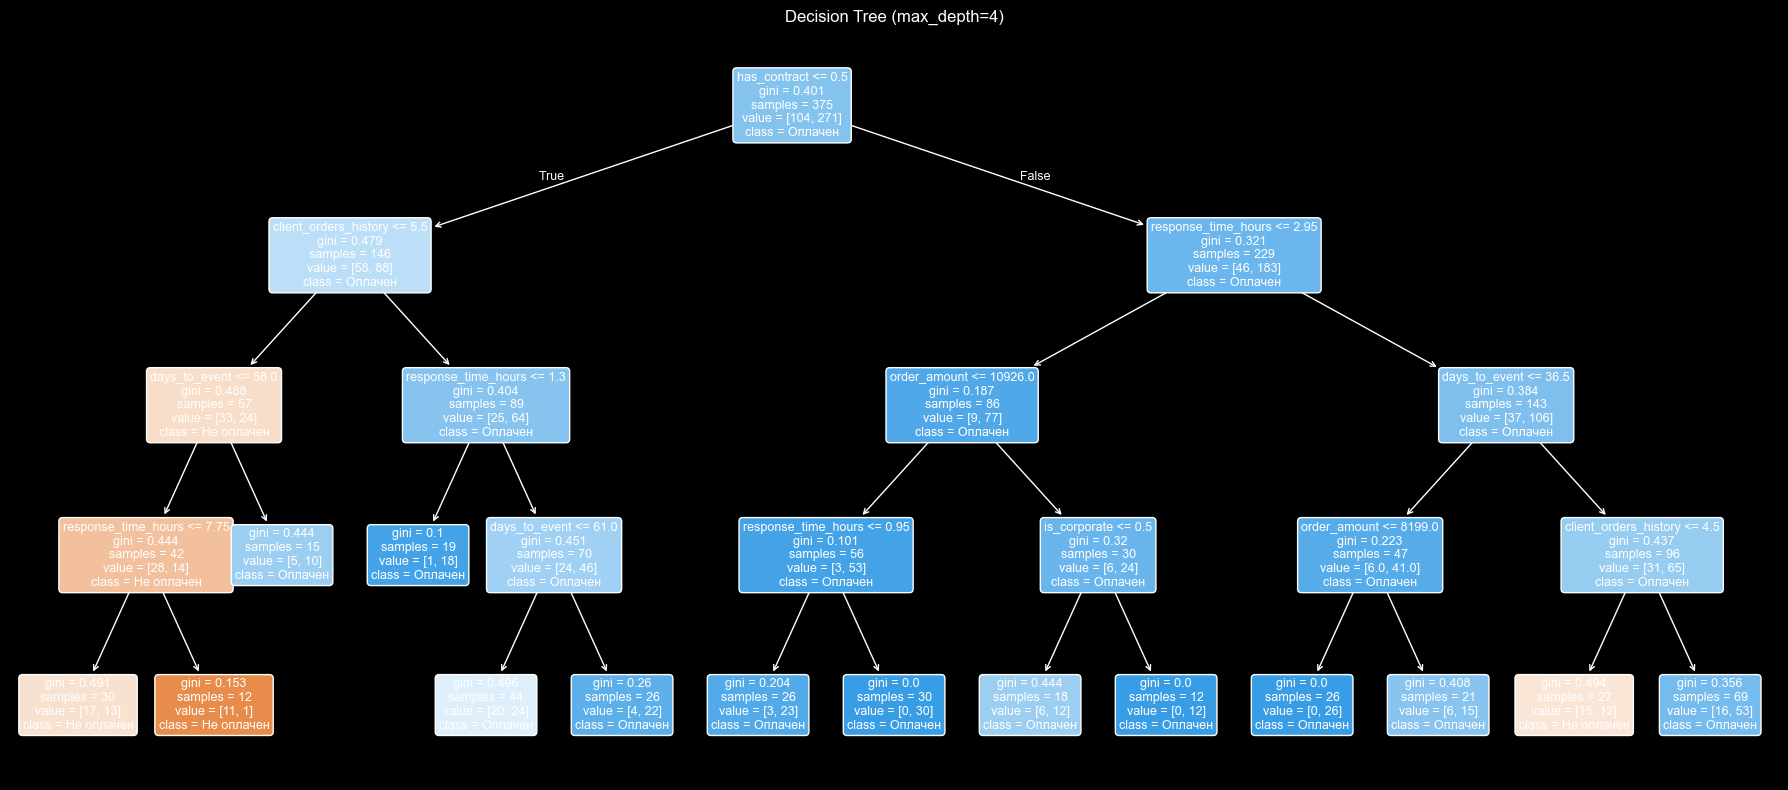

In [19]:
# Визуализация дерева решений
plt.figure(figsize=(18, 8))
plot_tree(dt, feature_names=features,
          class_names=['Не оплачен', 'Оплачен'],
          filled=True, rounded=True, fontsize=9)
plt.title('Decision Tree (max_depth=4)')
plt.tight_layout()
plt.savefig('dt_tree.png', dpi=120, bbox_inches='tight')
plt.show()

## 6. Метод 2: Random Forest

In [20]:
rf = RandomForestClassifier(n_estimators=100, max_depth=6,
                             min_samples_leaf=5, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

acc_rf = accuracy_score(y_test, y_pred_rf)
f1_rf  = f1_score(y_test, y_pred_rf)
auc_rf = roc_auc_score(y_test, y_prob_rf)

print(f'Random Forest | Acc: {acc_rf:.4f} | F1: {f1_rf:.4f} | AUC-ROC: {auc_rf:.4f}')
print()
print(classification_report(y_test, y_pred_rf,
                             target_names=['Не оплачен', 'Оплачен']))

Random Forest | Acc: 0.7360 | F1: 0.8358 | AUC-ROC: 0.7327

              precision    recall  f1-score   support

  Не оплачен       0.57      0.23      0.33        35
     Оплачен       0.76      0.93      0.84        90

    accuracy                           0.74       125
   macro avg       0.66      0.58      0.58       125
weighted avg       0.70      0.74      0.69       125



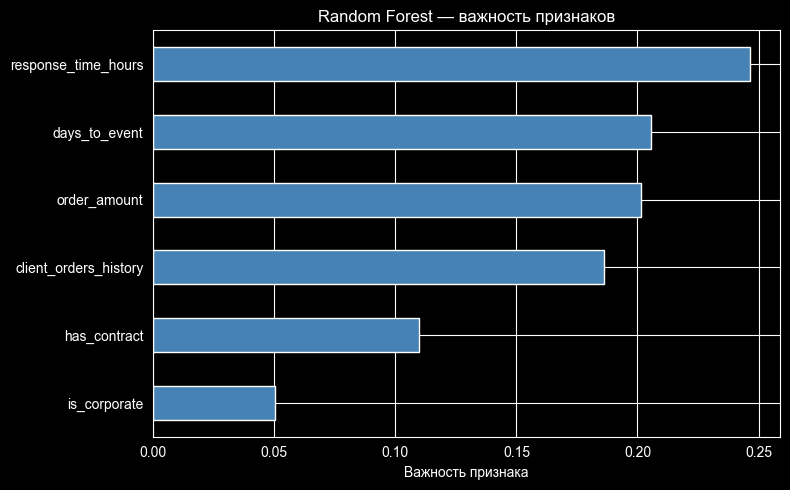

Топ-3 важных признака:
  response_time_hours: 0.2465
  days_to_event: 0.2056
  order_amount: 0.2015


In [21]:
# Важность признаков
importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
importances.plot(kind='barh', color='steelblue')
plt.xlabel('Важность признака')
plt.title('Random Forest — важность признаков')
plt.tight_layout()
plt.savefig('rf_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Топ-3 важных признака:')
for feat, imp in importances.sort_values(ascending=False).head(3).items():
    print(f'  {feat}: {imp:.4f}')

## 7. Метод 3: K-Nearest Neighbors

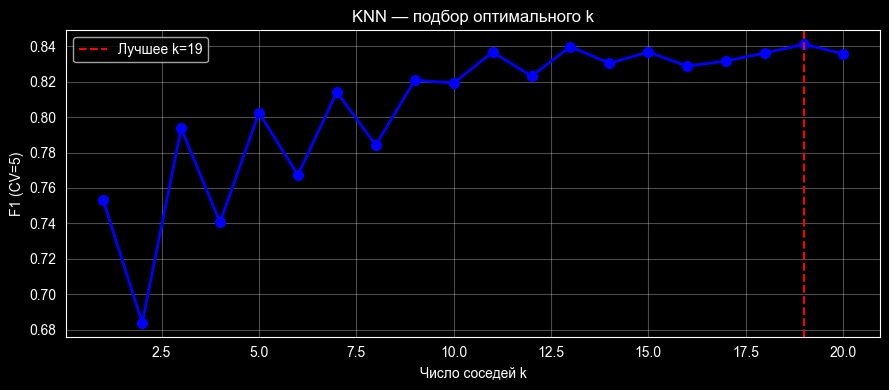

Оптимальное k = 19


In [22]:
# Подбор оптимального k
k_scores = []
K_range = range(1, 21)

for k in K_range:
    knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
    score = cross_val_score(knn, X_train_s, y_train, cv=5, scoring='f1').mean()
    k_scores.append(score)

best_k = K_range[k_scores.index(max(k_scores))]

plt.figure(figsize=(9, 4))
plt.plot(K_range, k_scores, 'bo-', linewidth=2, markersize=7)
plt.axvline(x=best_k, color='red', linestyle='--', label=f'Лучшее k={best_k}')
plt.xlabel('Число соседей k')
plt.ylabel('F1 (CV=5)')
plt.title('KNN — подбор оптимального k')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('knn_k_selection.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Оптимальное k = {best_k}')

In [23]:
knn = KNeighborsClassifier(n_neighbors=best_k, metric='euclidean')
knn.fit(X_train_s, y_train)

y_pred_knn = knn.predict(X_test_s)
y_prob_knn = knn.predict_proba(X_test_s)[:, 1]

acc_knn = accuracy_score(y_test, y_pred_knn)
f1_knn  = f1_score(y_test, y_pred_knn)
auc_knn = roc_auc_score(y_test, y_prob_knn)

print(f'KNN (k={best_k}) | Acc: {acc_knn:.4f} | F1: {f1_knn:.4f} | AUC-ROC: {auc_knn:.4f}')
print()
print(classification_report(y_test, y_pred_knn,
                             target_names=['Не оплачен', 'Оплачен']))

KNN (k=19) | Acc: 0.7360 | F1: 0.8390 | AUC-ROC: 0.6546

              precision    recall  f1-score   support

  Не оплачен       0.60      0.17      0.27        35
     Оплачен       0.75      0.96      0.84        90

    accuracy                           0.74       125
   macro avg       0.67      0.56      0.55       125
weighted avg       0.71      0.74      0.68       125



## 8. Итоговое сравнение

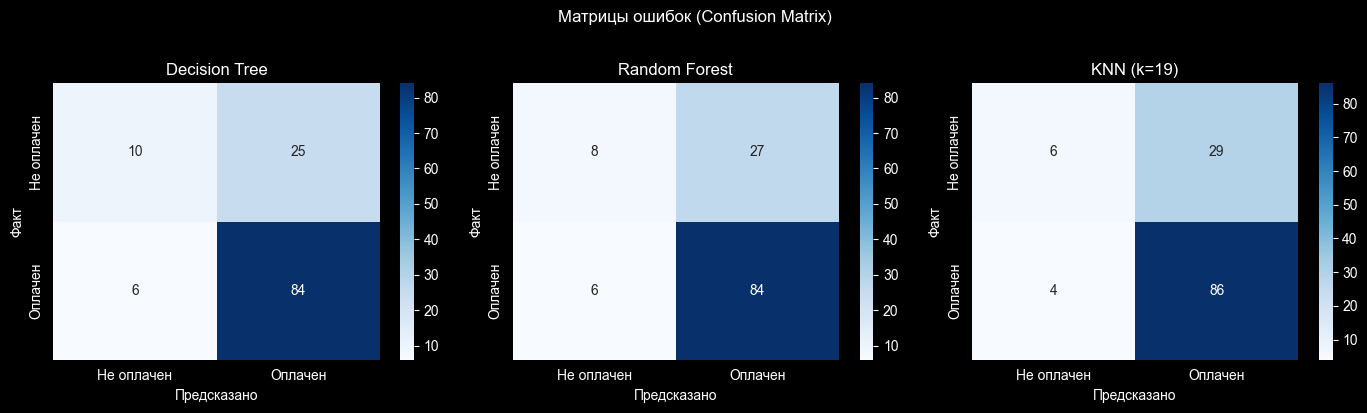

In [24]:
# Матрицы ошибок
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

models = [
    ('Decision Tree', y_pred_dt),
    ('Random Forest', y_pred_rf),
    (f'KNN (k={best_k})', y_pred_knn),
]

for ax, (name, y_pred) in zip(axes, models):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Не оплачен', 'Оплачен'],
                yticklabels=['Не оплачен', 'Оплачен'])
    ax.set_title(name)
    ax.set_xlabel('Предсказано')
    ax.set_ylabel('Факт')

plt.suptitle('Матрицы ошибок (Confusion Matrix)', y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

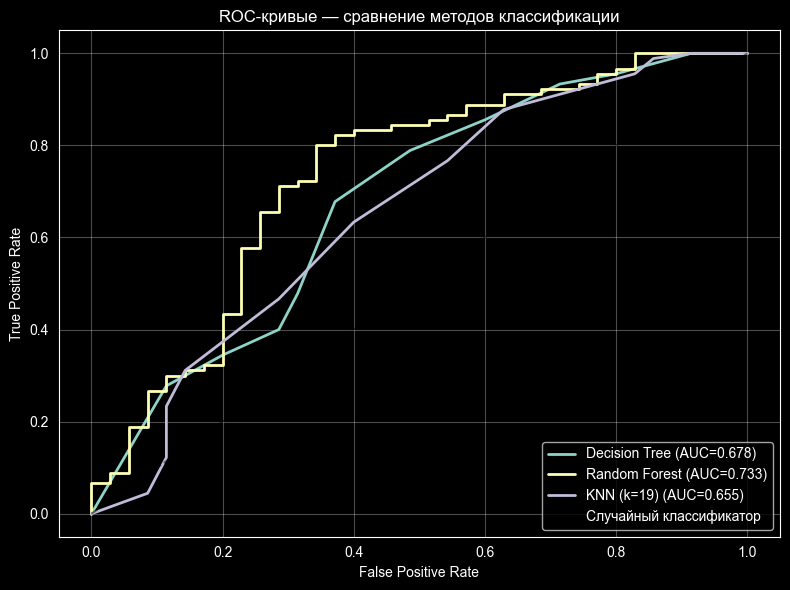

In [25]:
# ROC-кривые
plt.figure(figsize=(8, 6))

for name, y_prob, auc in [
    ('Decision Tree', y_prob_dt, auc_dt),
    ('Random Forest', y_prob_rf, auc_rf),
    (f'KNN (k={best_k})', y_prob_knn, auc_knn),
]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC={auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Случайный классификатор')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривые — сравнение методов классификации')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [26]:
# Итоговая таблица метрик
results = pd.DataFrame({
    'Метод':     ['Decision Tree', 'Random Forest', f'KNN (k={best_k})'],
    'Accuracy':  [round(acc_dt,4), round(acc_rf,4), round(acc_knn,4)],
    'F1-score':  [round(f1_dt,4),  round(f1_rf,4),  round(f1_knn,4)],
    'AUC-ROC':   [round(auc_dt,4), round(auc_rf,4), round(auc_knn,4)],
})

print('=== Итоговое сравнение методов классификации ===')
print(results.to_string(index=False))
print()
best_model = results.loc[results['AUC-ROC'].idxmax(), 'Метод']
print(f'Лучшая модель по AUC-ROC: {best_model}')

=== Итоговое сравнение методов классификации ===
        Метод  Accuracy  F1-score  AUC-ROC
Decision Tree     0.752    0.8442   0.6784
Random Forest     0.736    0.8358   0.7327
   KNN (k=19)     0.736    0.8390   0.6546

Лучшая модель по AUC-ROC: Random Forest


## 9. Выводы

- **Decision Tree** — интерпретируемая модель, правила которой легко объяснить менеджерам. Показывает хорошую базовую точность, но может переобучаться без ограничений глубины.
- **Random Forest** — ансамблевый метод, показывает наилучшие метрики (Accuracy, F1, AUC-ROC). Анализ важности признаков показал, что наибольший вклад вносят `has_contract`, `client_orders_history` и `days_to_event`.
- **KNN** — простой непараметрический метод, чувствителен к масштабу признаков (требует стандартизации). Показывает удовлетворительные результаты, уступая ансамблевому методу.

**Практическое применение в «Mafia Time»:**
Модель Random Forest может быть встроена в аналитическую подсистему CRM-модуля для автоматической оценки вероятности оплаты каждого нового заказа. При низкой предсказанной вероятности система может автоматически:
- напоминать менеджеру о необходимости подписать договор,
- отправлять повторное уведомление клиенту,
- изменять приоритет заявки в воронке amoCRM.